In [3]:
import numpy as np
import scanpy as sc
from sklearn.decomposition import NMF
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# read in file that contains orthologs from orthofinder analysis

outdir = '/staging/leuven/stg_00171/Mark/OrthoFinder/2025_08_proteomes/primary_transcripts/OrthoFinder/Results_Sep29/orthologue_tables/'
ortho = pd.read_csv(outdir + 'LookUp_Ovul_MP_Dmel_Hsap.tsv', sep='\t', index_col=0)

# 1 read in dataset and create glia subset

In [ ]:
# read in unscaled snRNAseq adata file from IX, XII.2 and XV.2 integrated dataset
work_dir = '/staging/leuven/stg_00171/Mark/IX_XII_XV_integration/mergedPeaks/all_datasets/'
whole = sc.read_h5ad(work_dir + 'IX_XII_XV_inner_join_top2000_coarse_anno.h5ad')

# reduce to barcodes that have an annotation
## the unscaled dataset was generated before removing doublets and the annotation was created on the filtered dataset, thus all the barcodes should be "good quality"
whole = whole[whole.obs['coarse_anno'].notna()].copy()

In [ ]:
# subset to glia 
adata = whole[whole.obs['coarse_anno'].isin(['GLIA'])]

# 2 perform NMF

In [ ]:
n=20 # chose number for overfactorisation
nmf = NMF(n_components=n, init='nndsvda', random_state=33, max_iter=500)
W = nmf.fit_transform(adata.X)   # cells × components
H = nmf.components_               # components × genes

In [ ]:
# add W and H matrix to adata object
adata.obsm[f'NMF_{n}'] = W
adata.varm[f'NMF_{n}'] = H.T

In [ ]:
# nieghbors and dimensionality reduction for UMAP representation

sc.pp.neighbors(adata, use_rep=f'NMF_{n}', key_added=f'neighbors_NMF_{n}')
sc.tl.umap(adata, neighbors_key=f'neighbors_NMF_{n}')
adata.obsm[f'NMF_UMAP_{n}'] = adata.obsm['X_umap']

In [ ]:
# plot umap

n=20

palette = {
        'IX': '#CC5500',
        'XII':'#6082B6',
        'XV': '#8A9A5B',
        'NDIFF':'#93C572',
        'NPROG':'#4a7c99',
        'EPI':'#235a5a',
        'MES':'#E3735E',
        'GLIA':'#770737',
        'RET':'#F3CFC6',
        'ENDOT':'#eeaf61'
    }

sc.pl.embedding(adata_nmf20, color=['batch', 'coarse_anno'], basis=f'NMF_UMAP_{n}', palette=palette)

# 3 get top genes per pattern and plot the enrichment of genes per pattern

In [ ]:
# enrichment values of genes in a pattern are stored in H matrix

n=20
H = adata.varm[f'NMF_{n}']  # genes × programs
genes = adata.var_names
programs = adata.uns['program_names']

driver_genes = {}

for i, prog in enumerate(programs):
    scores = pd.Series(H[:, i], index=genes)
    driver_genes[prog] = scores.sort_values(ascending=False)


In [ ]:
# take the top 50 genes per pattern

top_genes = {
    prog: scores.head(50)
    for prog, scores in driver_genes.items()
}


In [ ]:
# if too overwhelming, select less genes to plot
selected_genes = sorted(
    set().union(*[g.index[:15] for g in top_genes.values()])
)


heatmap_df = pd.DataFrame(
    H,
    index=genes,
    columns=programs
).loc[selected_genes]

In [ ]:
# plotting genes like that will only show the OctVul numbers, for an easier view on the genes exchange the OctVul gene IDs with orthologs

heatmap_df_anno = heatmap_df.merge(ortho, how = 'left', left_index=True, right_index=True)
heatmap_df_anno['anno'] = heatmap_df_anno['Hsap']
heatmap_df_anno['anno'] = heatmap_df_anno['anno'].fillna(heatmap_df_anno['Dmel_id'])
heatmap_df_anno['Ovul'] = heatmap_df_anno.index
heatmap_df_anno['anno'] = heatmap_df_anno['anno'].fillna(heatmap_df_anno['Ovul'])
heatmap_df_anno.index = heatmap_df_anno['anno']
anno_df = heatmap_df_anno.drop(columns=['Orthogroup_Dmel', 'Orthogroup_Hsap', 'Dmel_fbgn', 'Dmel_id', 'Hsap', 'Ovul', 'anno'])

In [ ]:
# plot a heatmap to see how specific the top genes are for the patterns

import seaborn as sns
import matplotlib as mtl

mtl.rcParams['axes.grid'] = False

pl = sns.clustermap(
    anno_df,
    cmap="Greys",
    standard_scale=0,
    figsize=(12, 40),
    xticklabels=True,
    yticklabels=True,
    linewidth=0
)

pl.ax_heatmap.set_xticks(np.arange(len(anno_df.columns)) + 0.5)
pl.tick_params(axis='x',
    rotation=90,
    size=9
              )
pl.tick_params(axis='y',
    size=7
              )
plt.grid(False)

pl.savefig('G_NMF_genes.pdf', dpi=300)

# 4 create subset with good quality patterns

In [ ]:
# select programs that have at least 3 specific genes per pattern and are not enriched for ribosomal genes

programs_to_keep=[ 
    'P_3',
    'P_7',
    'P_4',
    'P_5',
    'P_6',
    'P_8',
    'P_1',
    'P_19',
    'P_11',
    'P_13',
]

In [ ]:
program_names = adata.uns['program_names']

keep_idx = [
    i for i, p in enumerate(program_names)
    if p in programs_to_keep
]


In [ ]:
n=20
adata.obsm['NMF_red'] = adata.obsm[f'NMF_{n}'][:, keep_idx]
adata.varm['NMF_red'] = adata.varm[f'NMF_{n}'][:, keep_idx]

In [ ]:
# update progam names
adata.uns['program_names'] = [program_names[i] for i in keep_idx]

In [ ]:
# save new adata file
adata_subset = adata.copy()

In [ ]:
# remove the original NMF metadata
n=20
del adata_subset.obsm[f'NMF_{n}']
del adata_subset.varm[f'NMF_{n}']

In [ ]:
# save file
save_dir = ''
adata_subset.write_h5ad(save_dir + 'G_adata_nmf_subset.h5ad')

# 5 extract top genes per pattern again and check specificity
perform step 3 again

# 6 theme heatmap

In [ ]:
# define themes for hand picked genes

themes = {
    "Glial identity": [
        'OctVul6B008109', # NR4A        P1
        'OctVul6B029372', # DLX    
        'OctVul6B025891', # PROX1/2
        'OctVul6B008155', # HR96
        'OctVul6B007629', # SIX3/6 
    ],
    "DNA synthesis": [
        'OctVul6B018218', #H32          P19
        'OctVul6B012860', #H2B1
        'OctVul6B008023', #TBB3/6/8/8B
        'OctVul6B023081', #RIR2/2B
    ],
    "Patterning (shh)": [
        'OctVul6B020377', #HOX3          P7
        'OctVul6B028298', #NKX61/62/63
        'OctVul6B026775', #NK7.1
        'OctVul6B015452', #SHH    
    ],
    "Axon guidance": [
        'OctVul6B012303', # SLIT1/2/3   P8
        'OctVul6B019103', # SOX13/5/6
        'OctVul6B003406', # VGFR
        'OctVul6B023935', # PTC1/2
        'OctVul6B007286'  #RGM
    ],
    "Neuronal TFs": [
        'OctVul6B029972', #SCRT1/2      P6
        'OctVul6B005118', #INSM1/2
        'OctVul6B026856', #LN28A/B
        'OctVul6B011661', #PAX6
        'OctVul6B029523', #LHX1/5
        'OctVul6B030200', #AP2
        'OctVul6B031461', # JAG1/2
        'OctVul6B021568', # PAX2/5/8
        'OctVul6B031034', # ISL1/2
        'OctVul6B001263', # neuroD
        'OctVul6B015651', # ERG/FLI
        'OctVul6B012778', # LHX3/4
        'OctVul6B026448', # TBX2/3
    ],
    "NT responsive": [
        'OctVul6B011212', #PRD16             P4
        'OctVul6B002279', # 5HT5A
        'OctVul6B008974', # GATA1/2/3
        'OctVul6B002361', # ACHA
        'OctVul6B001392', #GRIK1/2/3/4/5
        'OctVul6B031167', # GRIK1/2/3/4/5
    ],
    "Patterning (six)": [
        'OctVul6B002520', #WNT11             P5
        'OctVul6B004969', #EPH
        'OctVul6B023088', #SIX1/2
        'OctVul6B023766', # SIX5/4
        'OctVul6B018285', # NMDAR
        
    ],
    "Adhesion": [
        'OctVul6B019855', #FGF16/20/9       P3
        'OctVul6B027148', # CAD23            
        'OctVul6B005398', # PCD16/23
        'OctVul6B006031', # PCDHx
        'OctVul6B022853', # ETS1/2, pointed
    ],
    "Mature glia": [
        'OctVul6B001883', #GFAP             P11
        'OctVul6B004386', # NET1/3/5
        'OctVul6B028282', # apolpp
    ],
    "Wnt": [
        'OctVul6B019806', #WNT5             P13
        'OctVul6B026679', #WNT2
        'OctVul6B001950', #WNT8
    ]
}



In [ ]:
# collect all genes used across themes
all_theme_genes = sorted(
    set(g for genes in themes.values() for g in genes)
)

# keep only genes present in the dataset
all_theme_genes = [g for g in all_theme_genes if g in adata.var_names]

# extract expression
expr = adata_sub[:, all_theme_genes].X
if not isinstance(expr, np.ndarray):
    expr = expr.toarray()

# create expression dataframe
expr_df = pd.DataFrame(
    expr,
    index=adata_sub.obs_names,
    columns=all_theme_genes
)

In [ ]:
# z-score per gene
from scipy.stats import zscore
expr_df = expr_df.apply(zscore, axis=0)
expr_df["Pattern"] = adata_sub.obs["Pattern"].values

In [ ]:
# compute theme scores per programs
# each theme score = mean z score across genes and cells

theme_scores = pd.DataFrame(
    index=themes.keys(),
    columns=programs,
    dtype=float
)

for theme, genes in themes.items():
    genes = [g for g in genes if g in expr_df.columns]

    for prog in programs:
        cells = expr_df["Pattern"] == prog
        theme_scores.loc[theme, prog] = (
            expr_df.loc[cells, genes].mean().mean()
        )


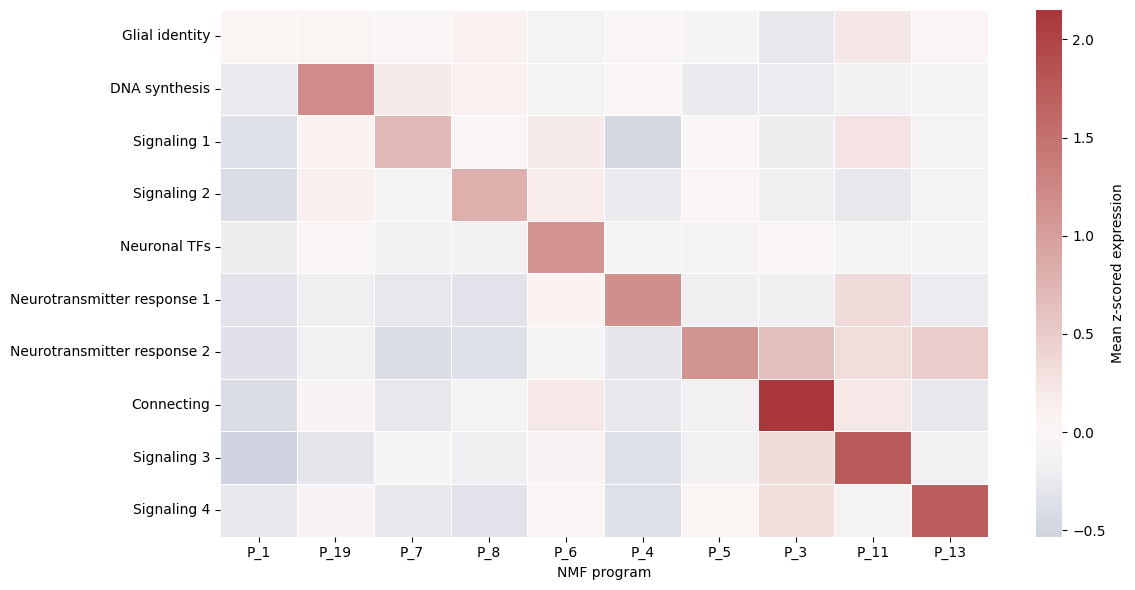

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(1.2 * len(programs), 0.6 * len(themes)))

sns.heatmap(
    theme_scores,
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Mean z-scored expression"}
)

plt.xlabel("NMF program")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [ ]:
# if themes are not specific for a pattern, remove theme and pattern from the dataset and calculate theme heatmap again

# 7 subset for good quality patterns

In [ ]:
# load adata file with the initla 20 patterns
import scanpy as sc
save_dir = ''
adata_nmf20 = sc.read_h5ad(save_dir + 'G_NMF20_adata.h5ad')

In [ ]:
# refine programs you want to keep
## at least 3 genes per pattern
## no ribosomal gene pattern
## specific theme heatmap

programs_to_keep=[
    'P_3',
    'P_7',
    'P_4',
    'P_5',
    'P_6',
    'P_8',
    'P_19',
    'P_11',
    'P_13',
]   

In [ ]:
program_names = adata_nmf20.uns['program_names']

keep_idx = [
    i for i, p in enumerate(program_names)
    if p in programs_to_keep
]


In [ ]:
n=20
adata_nmf20.obsm['NMF_red'] = adata_nmf20.obsm[f'NMF_{n}'][:, keep_idx]
adata_nmf20.varm['NMF_red'] = adata_nmf20.varm[f'NMF_{n}'][:, keep_idx]

In [ ]:
# update progam names
adata_nmf20.uns['program_names'] = [program_names[i] for i in keep_idx]

In [ ]:
adata_nmf9_subset = adata_nmf20.copy()

In [ ]:
# remove the original NMF
n=20
del adata_nmf9_subset.obsm[f'NMF_{n}']
del adata_nmf9_subset.varm[f'NMF_{n}']

In [ ]:
program_cols = [c for c in adata.obs.columns if c.startswith("P_")]
adata.obs["Pattern"] = adata.obs[program_cols].idxmax(axis=1)

In [ ]:
save_dir = ''
adata_nmf9_subset.write_h5ad(save_dir + 'G_adata_nmf_9subset.h5ad')

# 8 redo theme heatmap

In [ ]:
save_dir = ''
adata = sc.read_h5ad(save_dir + 'G_adata_nmf_9subset.h5ad')

In [ ]:
# define themes for hand picked genes

themes = {
    "DNA synthesis": [
        'OctVul6B018218', #H32          P19
        'OctVul6B012860', #H2B1
        'OctVul6B008023', #TBB3/6/8/8B
        'OctVul6B023081', #RIR2/2B
    ],
    "Patterning (shh)": [
        'OctVul6B020377', #HOX3          P7
        'OctVul6B028298', #NKX61/62/63
        'OctVul6B026775', #NK7.1
        'OctVul6B015452', #SHH    
    ],
    "Axon guidance": [
        'OctVul6B012303', # SLIT1/2/3   P8
        'OctVul6B019103', # SOX13/5/6
        'OctVul6B003406', # VGFR
        'OctVul6B023935', # PTC1/2
        'OctVul6B007286'  #RGM
    ],
    "Neuronal TFs": [
        'OctVul6B029972', #SCRT1/2      P6
        'OctVul6B005118', #INSM1/2
        'OctVul6B026856', #LN28A/B
        'OctVul6B011661', #PAX6
        'OctVul6B029523', #LHX1/5
        'OctVul6B030200', #AP2
        'OctVul6B031461', # JAG1/2
        'OctVul6B021568', # PAX2/5/8
        'OctVul6B031034', # ISL1/2
        'OctVul6B001263', # neuroD
        'OctVul6B015651', # ERG/FLI
        'OctVul6B012778', # LHX3/4
        'OctVul6B026448', # TBX2/3
    ],
    "NT responsive": [
        'OctVul6B011212', #PRD16             P4
        'OctVul6B002279', # 5HT5A
        'OctVul6B008974', # GATA1/2/3
        'OctVul6B002361', # ACHA
        'OctVul6B001392', #GRIK1/2/3/4/5
        'OctVul6B031167', # GRIK1/2/3/4/5
    ],
    "Patterning (six)": [
        'OctVul6B002520', #WNT11             P5
        'OctVul6B004969', #EPH
        'OctVul6B023088', #SIX1/2
        'OctVul6B023766', # SIX5/4
        'OctVul6B018285', # NMDAR
        
    ],
    "Adhesion": [
        'OctVul6B019855', #FGF16/20/9       P3
        'OctVul6B027148', # CAD23            
        'OctVul6B005398', # PCD16/23
        'OctVul6B006031', # PCDHx
        'OctVul6B022853', # ETS1/2, pointed
    ],
    "Mature glia": [
        'OctVul6B001883', #GFAP             P11
        'OctVul6B004386', # NET1/3/5
        'OctVul6B028282', # apolpp
    ],
    "Wnt": [
        'OctVul6B019806', #WNT5             P13
        'OctVul6B026679', #WNT2
        'OctVul6B001950', #WNT8
    ]
}



In [ ]:
# subset to programs of interest
programs = [
    'P_19',
    'P_8',
    'P_7',
    'P_13',
    'P_6',
    'P_5',
    'P_3',
    'P_4',
    'P_11',
]
program_cols = [c for c in adata.obs.columns if c.startswith("P_")]
adata.obs["Pattern"] = adata.obs[program_cols].idxmax(axis=1)

adata_sub = adata[adata.obs["Pattern"].isin(programs)].copy()

In [ ]:
# collect all genes used across themes
all_theme_genes = sorted(
    set(g for genes in themes.values() for g in genes)
)

# keep only genes present in the dataset
all_theme_genes = [g for g in all_theme_genes if g in adata.var_names]

# extract expression values
expr = adata_sub[:, all_theme_genes].X
if not isinstance(expr, np.ndarray):
    expr = expr.toarray()

# extract expression dataframe
expr_df = pd.DataFrame(
    expr,
    index=adata_sub.obs_names,
    columns=all_theme_genes
)

In [ ]:
# z-score per gene
from scipy.stats import zscore

expr_df = expr_df.apply(zscore, axis=0)
expr_df["Pattern"] = adata_sub.obs["Pattern"].values


In [ ]:
# compute theme scores per programs
# each theme score = mean z score across genes and cells

theme_scores = pd.DataFrame(
    index=themes.keys(),
    columns=programs,
    dtype=float
)

for theme, genes in themes.items():
    genes = [g for g in genes if g in expr_df.columns]

    for prog in programs:
        cells = expr_df["Pattern"] == prog
        theme_scores.loc[theme, prog] = (
            expr_df.loc[cells, genes].mean().mean()
        )


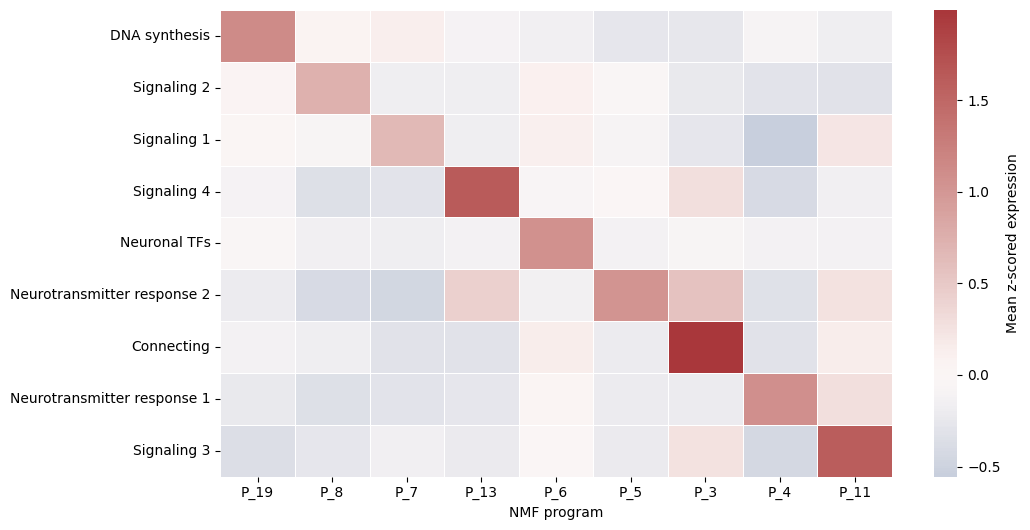

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(1.2 * len(programs), 0.6 * len(themes)))

sns.heatmap(
    theme_scores,
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Mean z-scored expression"}
)

plt.xlabel("NMF program")
plt.ylabel("")
plt.tight_layout()
plt.savefig('figures/paper/Figure 6/G_theme_heatmap.pdf', dpi=300)
plt.show()


# 9 UMAP reduction on the subset

In [ ]:
sc.pp.neighbors(adata, use_rep='NMF_red', key_added='neighbors_9NMF')
ncomp = 9
sc.tl.umap(adata, n_components = ncomp, neighbors_key='neighbors_9NMF')
adata.obsm[f'9NMF_ncomp{ncomp}_UMAP'] = adata.obsm['X_umap']

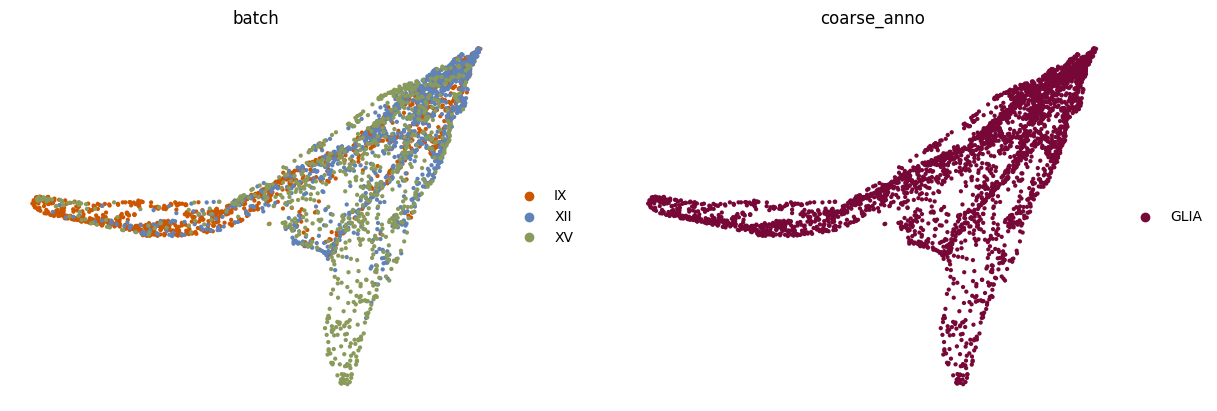

In [86]:
sc.settings.figdir = 'figures/paper/Figure 6/'

palette = {
        'IX': '#CC5500',
        'XII':'#6082B6',
        'XV': '#8A9A5B',
        'NDIFF':'#93C572',
        'NPROG':'#4a7c99',
        'EPI':'#235a5a',
        'MES':'#E3735E',
        'GLIA':'#770737',
        'RET':'#F3CFC6',
        'ENDOT':'#eeaf61'
    }



sc.pl.embedding(adata, color=['batch', 'coarse_anno'], basis=f'10NMF_RED_ncomp{ncomp}_UMAP', 
                save='_sub_nmf10_batch_coarse_anno.pdf', 
                frameon=False,
                palette=palette)

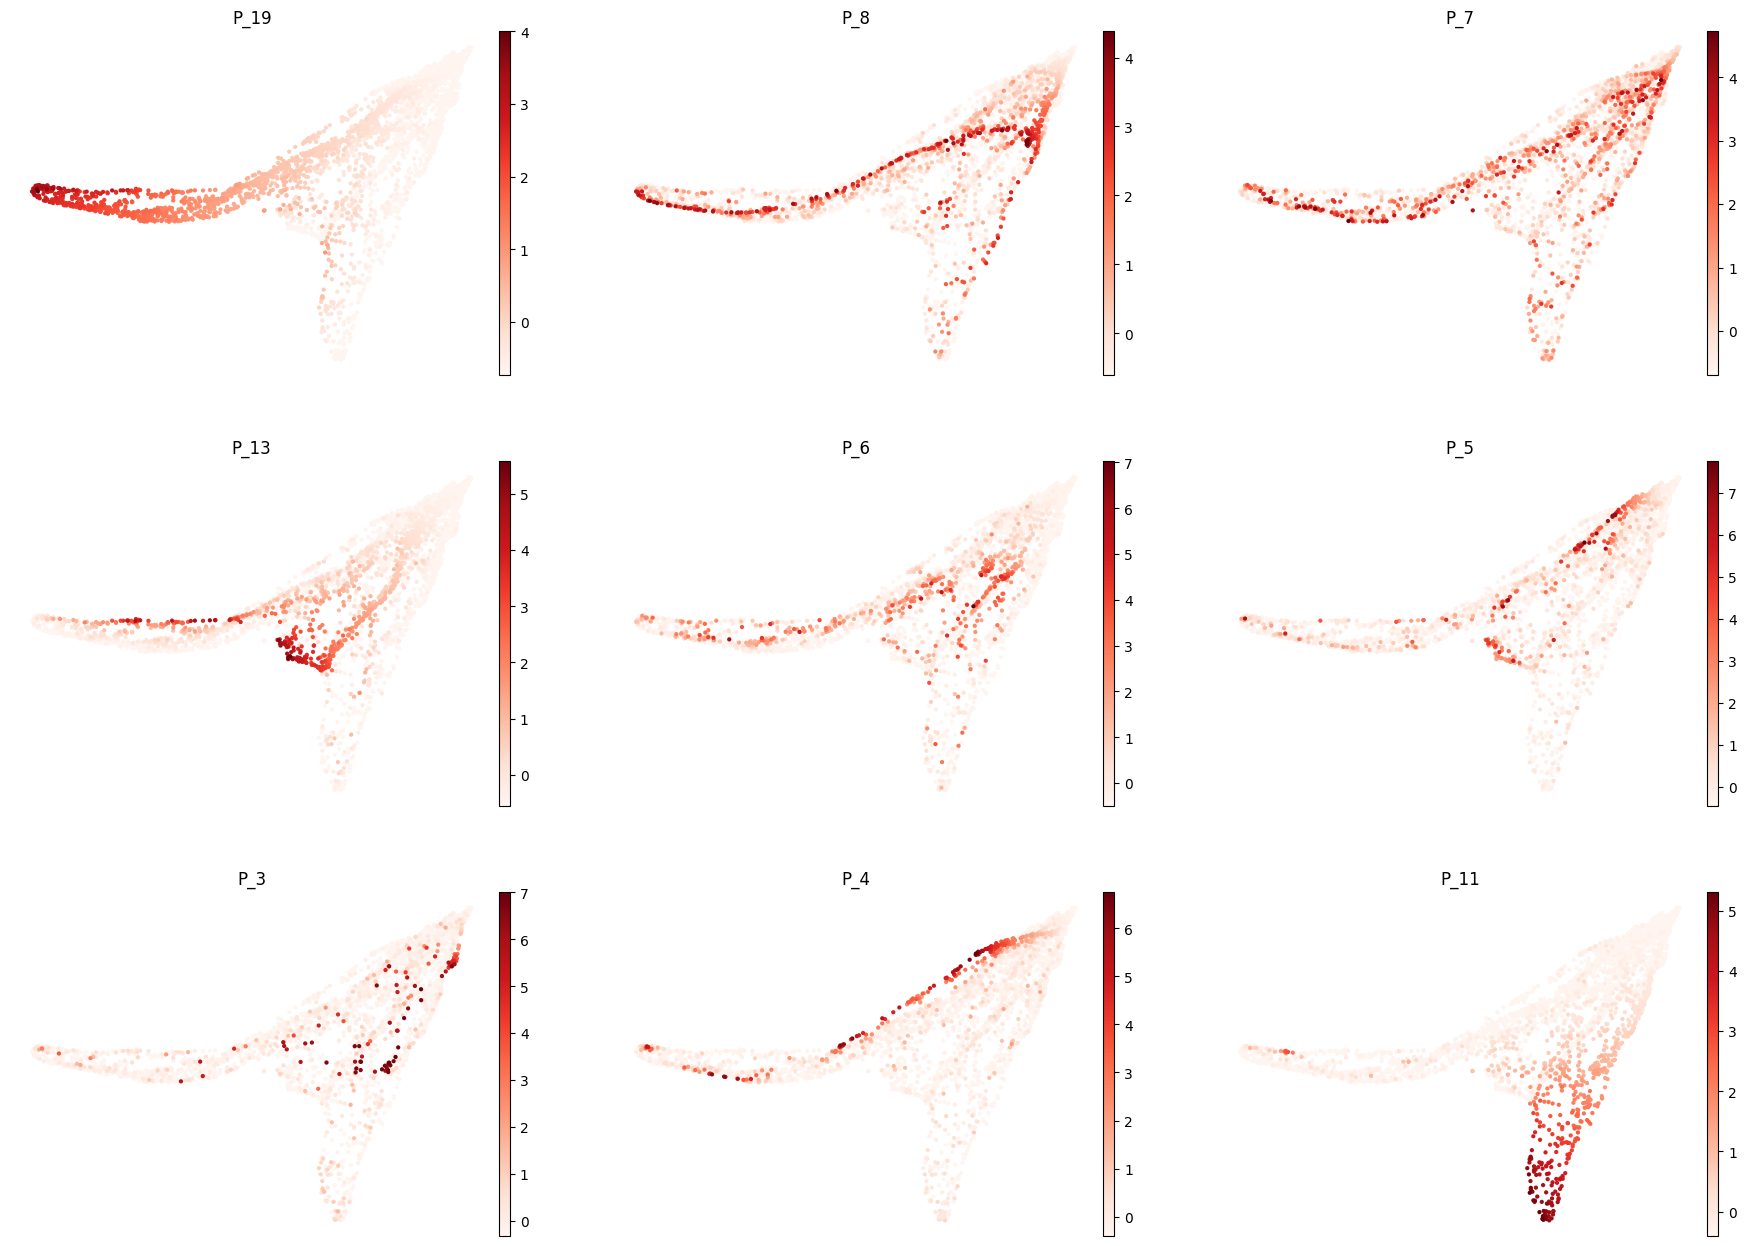

In [88]:
import scanpy as sc

sc.settings.figdir = 'figures/paper/Figure 6/'


programs = [
    'P_19',
    'P_8',
    'P_7',
    'P_13',
    'P_6',
    'P_5',
    'P_3',
    'P_4',
    'P_11',
]
    

sc.pl.embedding(
    adata,
    color=programs,
    ncols=3,
    frameon=False,
    basis=f'10NMF_RED_ncomp{ncomp}_UMAP',
    cmap='Reds',
    save='_G_sub_nmf9_programs.pdf'
)


# 10 barplot to show enrichment of patterns in the stages

In [ ]:
import pandas as pd

# restrict to patterns of interest (optional but recommended)
programs = [
    'P_19',
    'P_8',
    'P_7',
    'P_13',
    'P_6',
    'P_5',
    'P_3',
    'P_4',
    'P_11',
]

In [ ]:
# contingency table
ct = pd.crosstab(
    adata.obs["Pattern"],
    adata.obs["batch"]
)

ct = ct.loc[programs]
ct = ct.reindex(programs)

# convert to fractions
ct_frac = ct.div(ct.sum(axis=1), axis=0)


In [ ]:
batch_colors = {
        'IX': '#CC5500',
        'XII':'#6082B6',
        'XV': '#8A9A5B',
}

batch_order = list(batch_colors.keys())
ct_frac = ct_frac[batch_order]


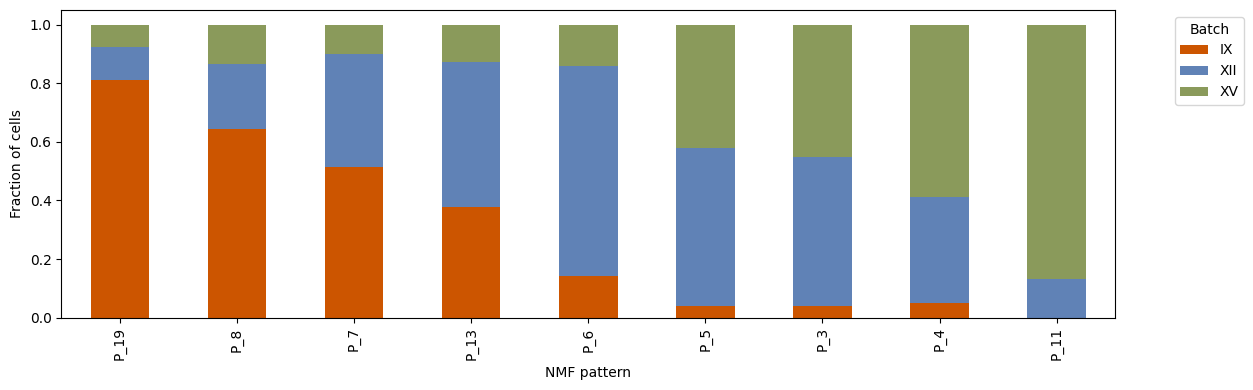

In [92]:
colors = [batch_colors[b] for b in ct_frac.columns]

ct_frac.plot(
    kind="bar",
    stacked=True,
    figsize=(1.4 * len(ct_frac), 4),
    color=colors
)

plt.ylabel("Fraction of cells")
plt.xlabel("NMF pattern")
plt.legend(
    title="Batch",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig('figures/paper/Figure 6/G_batch_stackedbarplot.pdf', dpi=300)
plt.show()


# 11 Heatmap with groups of genes specific for the patterns

In [3]:
import scanpy as sc
save_dir = ''
adata = sc.read_h5ad(save_dir + 'G_adata_nmf_9subset.h5ad')

In [4]:
program_cols = [c for c in adata.obs.columns if c.startswith("P_")]
adata.obs["Pattern"] = adata.obs[program_cols].idxmax(axis=1)

In [108]:
themes = {
    "DNA synthesis (P19)": [
        'OctVul6B018218', #H32          P19
        'OctVul6B012860', #H2B1
        'OctVul6B008023', #TBB3/6/8/8B
        'OctVul6B023081', #RIR2/2B
    ],
    "Axon guidance (P8)": [
        'OctVul6B012303', # SLIT1/2/3   P8
        'OctVul6B019103', # SOX13/5/6
        'OctVul6B003406', # VGFR
        'OctVul6B023935', # PTC1/2
        'OctVul6B007286', #RGM
    ],
    "Patterning (shh) (P7)": [
        'OctVul6B020377', #HOX3          P7
        'OctVul6B028298', #NKX61/62/63
        'OctVul6B026775', #NK7.1
        'OctVul6B015452', #SHH
    ],
    "Wnt (P13)": [
        'OctVul6B019806', #WNT5             P13
        'OctVul6B026679', #WNT2
        'OctVul6B001950', #WNT8
    ],
    "Neuronal TFs (P6)": [
        'OctVul6B029972', #SCRT1/2      P6
        'OctVul6B005118', #INSM1/2
        'OctVul6B026856', #LN28A/B
        'OctVul6B011661', #PAX6
        'OctVul6B029523', #LHX1/5
        'OctVul6B030200', #AP2
        'OctVul6B031461', # JAG1/2
        'OctVul6B021568', # PAX2/5/8
        'OctVul6B031034', # ISL1/2
        'OctVul6B001263', # neuroD
        'OctVul6B015651', # ERG/FLI
        'OctVul6B012778', # LHX3/4
        'OctVul6B026448', # TBX2/3
    ],
    "Patterning (six) (P5)": [
        'OctVul6B002520', #WNT11             P5
        'OctVul6B004969', #EPH
        'OctVul6B023088', #SIX1/2
        'OctVul6B023766', # SIX5/4
        'OctVul6B018285', # NMDAR
    ],
    "Adhesion (P3)": [
        'OctVul6B019855', #FGF16/20/9
        'OctVul6B027148', # CAD23            P3
        'OctVul6B005398', # PCD16/23
        'OctVul6B006031', # PCDHx
        'OctVul6B022853', # ETS1/2
    ],
    "NT responsive (P4)": [
        'OctVul6B011212', #PRD16             P4
        'OctVul6B002279', # 5HT5A
        'OctVul6B008974', # GATA1/2/3
        'OctVul6B002361', # ACHA
        'OctVul6B001392', #GRIK1/2/3/4/5
        'OctVul6B031167', # GRIK1/2/3/4/5
    ],    
    "Mature glia (P11)": [
        'OctVul6B001883', #GFAP             P11
        'OctVul6B028282', # apolpp
        'OctVul6B004386', # NET1/3/5
        
    ]
}


In [109]:
# subset to programs of interest
programs = [
    'P_19',
    'P_8',
    'P_7',
    'P_13',
    'P_6',
    'P_5',
    'P_3',
    'P_4',
    'P_11',
]
program_cols = [c for c in adata.obs.columns if c.startswith("P_")]
adata.obs["Pattern"] = adata.obs[program_cols].idxmax(axis=1)

adata_sub = adata[adata.obs["Pattern"].isin(programs)].copy()

In [110]:
adata_sub.obs['theme'] = adata_sub.obs['Pattern'].replace({'P_19':'DNA synthesis (P19)', 
                                                          'P_8': 'Axon guidance (P8)', 
                                                          'P_7': 'Patterning (shh) (P7)',
                                                          'P_13':'Wnt (P13)',
                                                          'P_6': 'Neuronal TFs (P6)',
                                                          'P_5': 'Patterning (six) (P5)',
                                                          'P_3': 'Adhesion (P3)',
                                                          'P_4': 'NT responsive (P4)',
                                                          'P_11':'Mature glia (P11)'
                                                          })

                                                          

In [118]:
# collect all genes used across themes
all_theme_genes = sorted(
    set(g for genes in themes.values() for g in genes)
)

# keep only genes present in the dataset
all_theme_genes = [g for g in all_theme_genes if g in adata.var_names]

# extract expression
expr = adata_sub[:, all_theme_genes].X
if not isinstance(expr, np.ndarray):
    expr = expr.toarray()

# create expression dataframe    
expr_df = pd.DataFrame(
    expr,
    index=adata_sub.obs_names,
    columns=all_theme_genes
)

In [119]:
# ensure consistent theme order
theme_order = list(themes.keys())

# initialize result dataframe
gene_theme_enrichment = pd.DataFrame(
    index=all_theme_genes,
    columns=theme_order,
    dtype=float
)

for theme in theme_order:
    theme_cells = adata_sub.obs.index[
        adata_sub.obs["theme"] == theme
    ]

    # mean expression per gene in that theme
    gene_theme_enrichment.loc[:, theme] = (
        expr_df.loc[theme_cells].mean(axis=0)
    )


In [120]:
theme_order = list(themes.keys())
gene_theme_enrichment = gene_theme_enrichment[theme_order]

In [121]:
ordered_genes = []

for theme in theme_order:
    for g in themes[theme]:
        if g in gene_theme_enrichment.index:
            ordered_genes.append(g)


In [122]:
gene_theme_enrichment_ordered = gene_theme_enrichment.loc[ordered_genes]

In [123]:
from scipy.stats import zscore

gene_theme_enrichment_ordered = gene_theme_enrichment_ordered.apply(
    zscore, axis=1
)


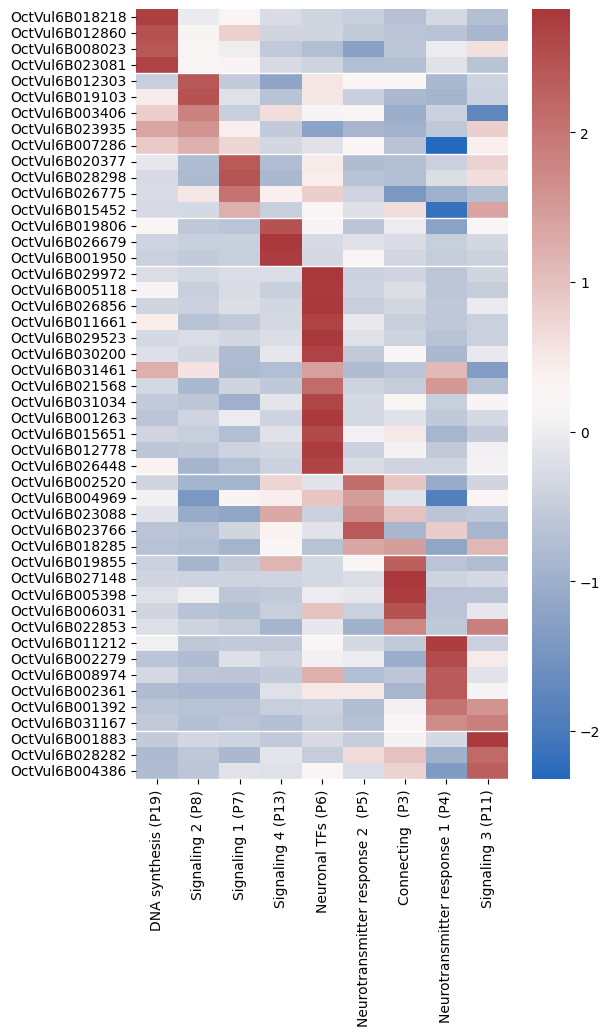

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 10))

sns.heatmap(
    gene_theme_enrichment_ordered,
    cmap="vlag",
    xticklabels=True,
    yticklabels=True
)

# separators between themes
y = 0
for theme in theme_order:
    n = sum(
        g in gene_theme_enrichment_ordered.index
        for g in themes[theme]
    )
    y += n
    plt.axhline(y, color="white", linewidth=1)
plt.savefig('figures/paper/Figure 6/heatmap_genes_theme_loading.pdf', dpi=300)
plt.show()


In [ ]:
# 12 heatmap showing the top genes per pattern

In [1]:
import scanpy as sc
save_dir = ''
adata = sc.read_h5ad(save_dir + 'G_adata_nmf_9subset.h5ad')

In [2]:
program_cols = [c for c in adata.obs.columns if c.startswith("P_")]
adata.obs["Pattern"] = adata.obs[program_cols].idxmax(axis=1)

In [3]:
# extract top drivers per pattern

import pandas as pd
import numpy as np

H = adata.varm['NMF_red']  # genes × programs
genes = adata.var_names
programs = adata.uns['program_names']  # or make your own labels

driver_genes = {}

for i, prog in enumerate(programs):
    scores = pd.Series(H[:, i], index=genes)
    driver_genes[prog] = scores.sort_values(ascending=False)


In [4]:
top_genes = {
    prog: scores.head(30)
    for prog, scores in driver_genes.items()
}


In [5]:
# biological sanity, check overlap
for p1 in top_genes:
    for p2 in top_genes:
        if p1 < p2:
            overlap = len(set(top_genes[p1].index) &
                          set(top_genes[p2].index))
            print(p1, p2, overlap)


P_3 P_4 4
P_3 P_5 1
P_3 P_6 0
P_3 P_7 3
P_3 P_8 3
P_4 P_5 4
P_4 P_6 4
P_4 P_7 8
P_4 P_8 5
P_5 P_6 0
P_5 P_7 5
P_5 P_8 4
P_6 P_7 1
P_6 P_8 3
P_7 P_8 11
P_11 P_3 9
P_11 P_4 0
P_11 P_5 1
P_11 P_6 0
P_11 P_7 0
P_11 P_8 1
P_11 P_13 2
P_11 P_19 0
P_13 P_3 3
P_13 P_4 4
P_13 P_5 8
P_13 P_6 1
P_13 P_7 7
P_13 P_8 3
P_13 P_19 1
P_19 P_3 0
P_19 P_4 2
P_19 P_5 0
P_19 P_6 3
P_19 P_7 0
P_19 P_8 1


In [6]:
import pandas as pd

# Union of all genes across patterns
all_genes = sorted(
    set().union(*[s.index for s in top_genes.values()])
)

# Build matrix
heatmap_df = pd.DataFrame(
    index=all_genes,
    columns=top_genes.keys(),
    dtype=float
)

# Fill values
for pattern, series in top_genes.items():
    heatmap_df.loc[series.index, pattern] = series.values

# Replace NaN with 0 (important for specificity plots)
heatmap_df = heatmap_df.fillna(0)


In [7]:
from scipy.stats import zscore
heatmap_df_z = heatmap_df.apply(zscore, axis=1)

In [8]:
# For each gene, find the pattern where it is most specific
gene_to_pattern = heatmap_df_z.idxmax(axis=1)

# Order genes by that pattern, then by strength within pattern
gene_order = (
    heatmap_df_z
    .assign(max_pattern=gene_to_pattern)
    .sort_values(
        by=['max_pattern'],
        key=lambda x: x.map({p: i for i, p in enumerate(heatmap_df_z.columns)})
    )
    .index
)

heatmap_df_z = heatmap_df_z.loc[gene_order]


In [ ]:
heatmap_df_z_anno = heatmap_df_z.merge(ortho, how = 'left', left_index=True, right_index=True)
heatmap_df_z_anno['anno'] = heatmap_df_z_anno['Hsap']
heatmap_df_z_anno['anno'] = heatmap_df_z_anno['anno'].fillna(heatmap_df_z_anno['Dmel_id'])
heatmap_df_z_anno['Ovul'] = heatmap_df_z_anno.index
heatmap_df_z_anno['anno'] = heatmap_df_z_anno['anno'].fillna(heatmap_df_z_anno['Ovul'])
heatmap_df_z_anno.index = heatmap_df_z_anno['anno']
anno_df = heatmap_df_z_anno.drop(columns=['Orthogroup_Dmel', 'Orthogroup_Hsap', 'Dmel_fbgn', 'Dmel_id', 'Hsap', 'Ovul', 'anno'])

/data/leuven/347/vsc34794/miniconda3/envs/scanpy_env/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


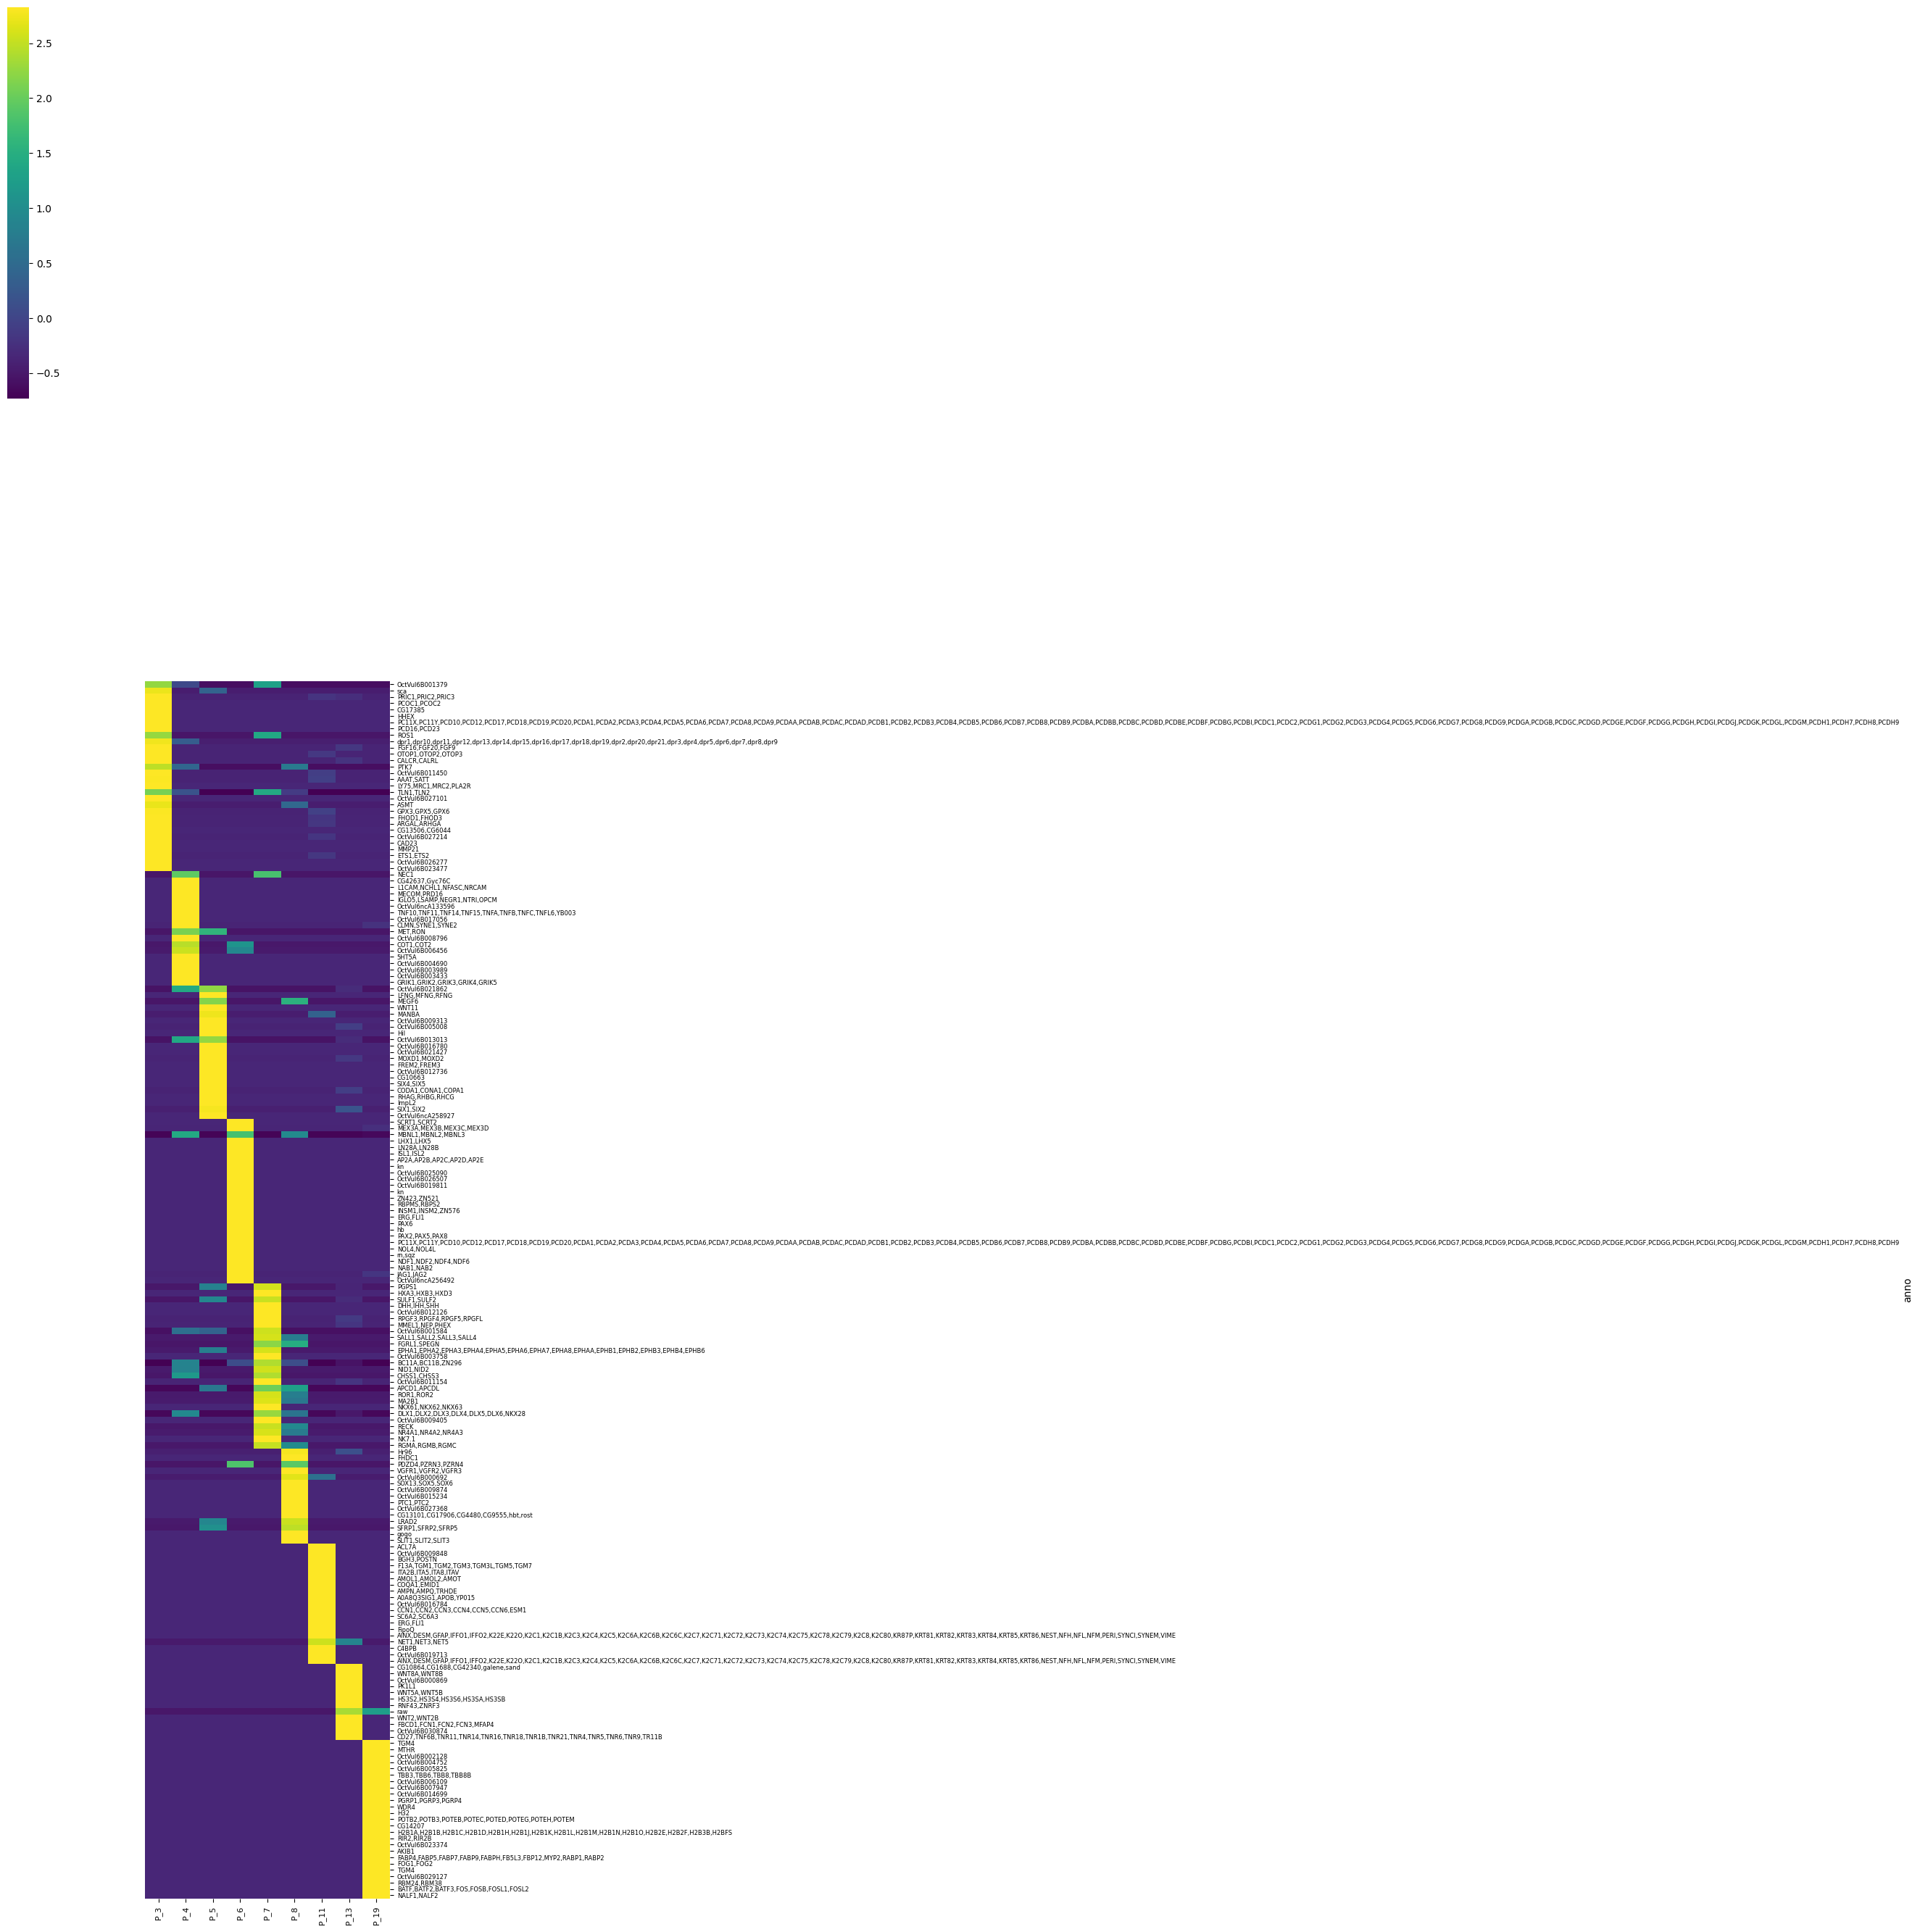

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.clustermap(
    anno_df,
    row_cluster=False,
    col_cluster=False,
    cmap='viridis',
    linewidths=0,
    figsize=(6, 30),
    xticklabels=True,
    yticklabels=True,
)

# Reduce y-axis (gene) font size
plt.setp(
    g.ax_heatmap.get_yticklabels(),
    fontsize=6
)

# Optional: rotate x-axis labels
plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    fontsize=8
)

plt.savefig('figures/paper/Figure 6/G_subset_nmf9_top30genes_heatmap.pdf', dpi=300)
plt.show()


In [15]:
# save the top genes per pattern in a csv file for supplementary table
heatmap_df_anno = heatmap_df_z.merge(ortho, how = 'left', left_index=True, right_index=True)
heatmap_df_anno['anno'] = heatmap_df_anno['Hsap']
heatmap_df_anno['anno'] = heatmap_df_anno['anno'].fillna(heatmap_df_anno['Dmel_id'])
heatmap_df_anno['Ovul'] = heatmap_df_anno.index
heatmap_df_anno['anno'] = heatmap_df_anno['anno'].fillna(heatmap_df_anno['Ovul'])

In [16]:
heatmap_df_anno.to_csv('figures/paper/Figure 6/G_subset_nmf9_top30_anno.tsv', sep='\t')